In [1]:
import os
import glob

import torch
torch.set_default_dtype(torch.double)
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision  
import matplotlib.pyplot as plt
from tqdm import tqdm
from nflows.transforms.normalization import ActNorm
from nflows.transforms import OneByOneConvolution, SqueezeTransform

# embeddings
from src.embedding.hyperbolic_gromov_monge import HyperbolicGromovMongeEmbedding

# diffeomorphisms
from src.diffeomorphisms.image.starflow import StarFlowImageDiffeomorphism

# manifolds
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.manifolds.euclidean.image.standard import StandardImageEuclidean

# training
from src.training.diffeomorphic_decoder import DiffeomorphicDecoderTraining
from src.training.hyperbolic_gromov_monge_embedding import HyperbolicGromovMongeEmbeddingTraining
from src.training.trimmed_ellipsoid_starflow import TrimmedEllipsoidStarFlowTraining

# transforms
from src.transforms.composite.image import ImageCompositeTransform
from src.transforms.image import ImageTransform
from src.transforms.image.parity_conv.linear_2d import Linear2DParityConvImageTransform
from src.transforms.image.parity_conv.simple_tanh_2d import SimpleTanh2DParityConvImageTransform

from config_loader import load_experiment_config 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# settings
n_clusters = 10
trimmed = True

# results folder


# set random seed
torch.manual_seed(31)

# ---- load YAML config ----
config = load_experiment_config("configs/mnist/hgme_decoder_+_multi_trimmed_ellipsoid_starflow.yaml", "mnist_32")

data_cfg = config["data"]
emb_cfg = config["emb"]
phi_cfg = config["phi"]
starflow_cfg = config["starflow"]

size = data_cfg["size"]
batch_size = data_cfg["batch_size"]

emb_training = emb_cfg["enabled"]
phi_training = phi_cfg["enabled"]
starflow_training = starflow_cfg["enabled"]

assert (emb_cfg["latent_dim"] == (size // (2 ** phi_cfg["n_scales"])) ** 2)
latent_dim = emb_cfg["latent_dim"]

base_results_folder = os.path.join("results", "mnist", "hgme_decoder_+_multi_trimmed_ellipsoidal_starflow")
os.makedirs(base_results_folder, exist_ok=True)

results_folder = os.path.join(
    base_results_folder,
    f"{size}x{size}",
)
os.makedirs(results_folder, exist_ok=True)


In [2]:
H = W = size
mnist_mean = data_cfg["mnist_mean"]
mnist_var = data_cfg["mnist_var"]
train_val_split = data_cfg["train_val_split"]

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

full_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Collect all images and labels
data = []
labels = []

for x, y in full_dataset:
    data.append(x)          # x has shape 1 x H x W
    labels.append(y)

# Stack into tensors
data = torch.stack(data, dim=0)        # shape: N x 1 x H x W
labels = torch.tensor(labels, dtype=torch.long)  # shape: N

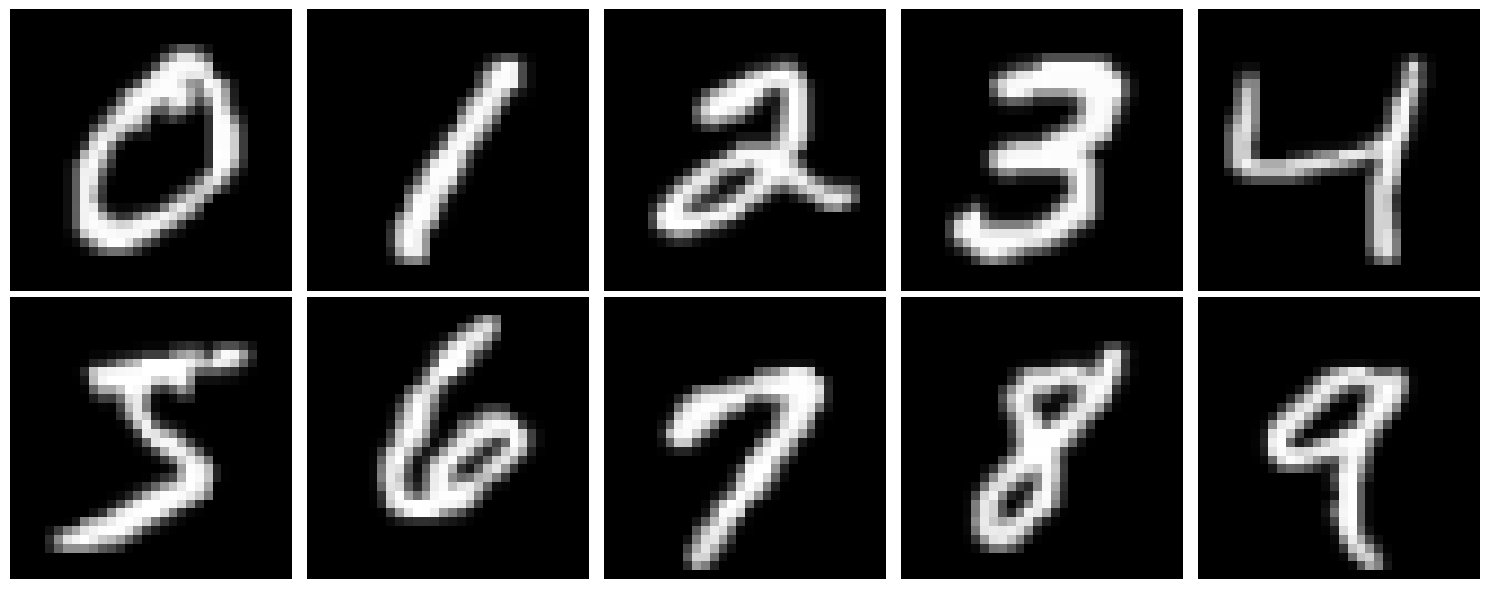

In [3]:
# construct data clusters as one digit per class
data_clusters = torch.zeros((10, 1, H, W))  # placeholder for cluster images
for digit in range(10):
    digit_indices = (labels == digit)
    data_clusters[digit] = data[digit_indices][0]

labels_clusters = torch.arange(10)

# plot cluster images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(data_clusters[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# construct train and val datasets
data_size = data.shape[0]
train_size = int(train_val_split * data_size)
val_size = data_size - train_size
idx = torch.randperm(data_size)
train_idx, val_idx = idx[:train_size], idx[train_size:]
data_train, data_val = data[train_idx], data[val_idx]
labels_train, labels_val = labels[train_idx], labels[val_idx]

print("Data shapes: \n data.shape = {} \n data_train.shape = {} \n data_val.shape = {}".format(data.shape, data_train.shape, data_val.shape))

Data shapes: 
 data.shape = torch.Size([60000, 1, 32, 32]) 
 data_train.shape = torch.Size([48000, 1, 32, 32]) 
 data_val.shape = torch.Size([12000, 1, 32, 32])


In [5]:
class RandomPairDataset(Dataset):
    def __init__(self, data):
        self.data = data            # shape: N x d
        self.N = data.shape[0]

    def __len__(self):
        return self.N  # you can pick another value if you wish

    def __getitem__(self, idx):
        # x: deterministic sample (makes training deterministic per epoch)
        x = self.data[idx]
        # x_prime: random sample, different from idx
        idx2 = torch.randint(0, self.N - 1, (1,)).item()
        if idx2 >= idx:
            idx2 += 1
        x_prime = self.data[idx2]
        return x, x_prime
    
# create dataset and dataloader
train_pair_dataset = RandomPairDataset(data_train)
train_loader = DataLoader(train_pair_dataset, batch_size=batch_size, shuffle=True)

## Learn Diffeomorphism ##

### Part I: Learn Embedding ###

In [6]:
# construct Gromov-Monge Embedding in Hyperbolic Space
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.block(x))

class ResidualCNN(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # size/2
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            ResidualBlock(64),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # size/4
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            ResidualBlock(128),
        )
        self.fc1 = nn.Linear(128, 512)
        self.fc2 = nn.Linear(512, latent_dim)

    def forward(self, x):
        # x: [B, 1, H, W] with arbitrary H=W=size
        x = self.conv(x)              # [B, 128, H', W']
        x = x.mean(dim=(2, 3))        # global average pooling -> [B, 128]
        x = F.relu(self.fc1(x))       # [B, 512]
        z = self.fc2(x)               # [B, latent_dim]
        return z
        
class ResidualCNNHyperbolicGromovMongeEmbedding(HyperbolicGromovMongeEmbedding):
    def __init__(self, output_dim):
        nn_model = ResidualCNN(output_dim)
        super().__init__(nn_model, output_dim=output_dim)

emb_trainer = HyperbolicGromovMongeEmbeddingTraining(
    ResidualCNNHyperbolicGromovMongeEmbedding(latent_dim).to(device),
    reg_param=emb_cfg["reg_param"],
    lr=emb_cfg["learning_rate"],
)

In [7]:
# construct train loop
def emb_train(trainer, train_loader, save_dir, n_epochs, start_epoch=0, best_loss=float('inf'), save_every=5):
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        for x, x_prime in tqdm(train_loader):
            x = x.to(device, non_blocking=True)
            x_prime = x_prime.to(device, non_blocking=True)
            loss = trainer.train_step(x, x_prime)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(train_pair_dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': trainer.emb.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_loss,
        }
        
        if (epoch+1) % save_every == 0 or (epoch+1) == n_epochs: 
            torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [8]:
# train or load model for phase 1
emb_extension = f"lr_{emb_cfg['learning_rate']}_reg_{emb_cfg['reg_param']}_latent_{emb_cfg['latent_dim']}"
checkpoint_dir = os.path.join(results_folder, emb_cfg["checkpoint_subdir"], emb_extension)
os.makedirs(checkpoint_dir, exist_ok=True)

if emb_training:
    start_epoch = 0
    best_loss = float('inf')
    latest_checkpoint = max(
        glob.glob(os.path.join(checkpoint_dir, "epoch_*_model.pth")),
        default=None,
        key=os.path.getctime,
    )

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        emb_trainer.emb.load_state_dict(checkpoint["model_state_dict"])
        emb_trainer.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        best_loss = checkpoint["best_loss"]

    emb_train(
        emb_trainer,
        train_loader,
        save_dir=checkpoint_dir,
        n_epochs=emb_cfg["num_epochs"],
        start_epoch=start_epoch,
        best_loss=best_loss,
    )
else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    checkpoint = torch.load(best_model_path, map_location=device)
    emb_trainer.emb.load_state_dict(checkpoint["model_state_dict"])


In [9]:
emb = emb_trainer.emb

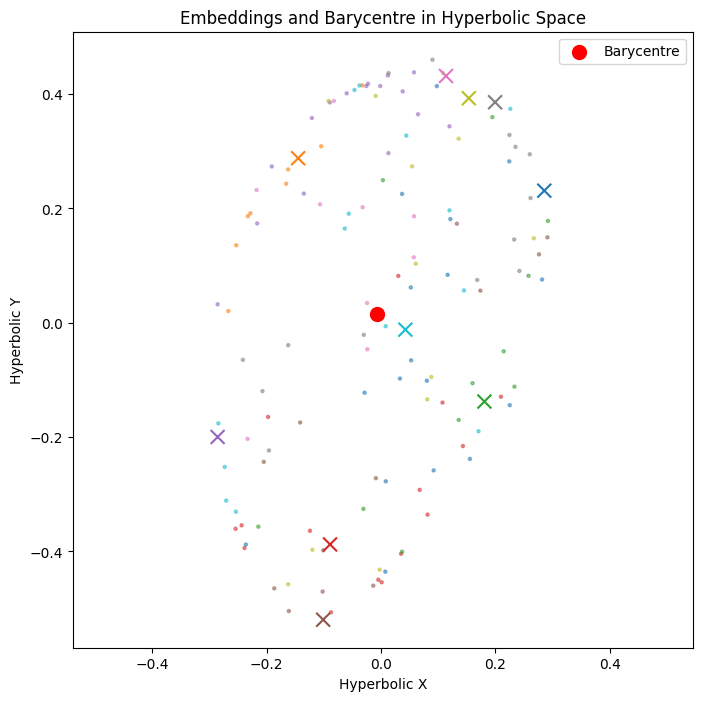

In [10]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    embeddings_train = emb(data_train[:batch_size].to(device)).cpu()
    embeddings_clusters = emb(data_clusters.to(device)).cpu()
    embeddings_barycentre = emb.barycentre(data_train[:batch_size].to(device), max_iter=500, step_size=0.1).cpu()

plt.figure(figsize=(8, 8))
plt.scatter(embeddings_train[:, 0], embeddings_train[:, 1], c=labels_train[:batch_size], s=5, alpha=0.5, cmap='tab10')
plt.scatter(embeddings_clusters[:, 0], embeddings_clusters[:, 1], c=labels_clusters, marker='x', s=100, cmap='tab10')
plt.scatter(embeddings_barycentre[0].item(), embeddings_barycentre[1].item(), color='red', marker='o', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.savefig(os.path.join(results_folder,"emb_final.png"))
plt.show()  

### Part II: Learn Diffeomorphic Decoder ###

In [11]:
class MultiLevelImageTransform(ImageTransform):
    def __init__(self, in_channels, height, width, image_transforms):
        """
        :param image_transforms: list of ImageTransform objects, one for each level of the multi-level transform.
        """
        self.L = len(image_transforms)
        assert image_transforms[0].C == in_channels * 4
        assert image_transforms[0].H == height // 2
        assert image_transforms[0].W == width // 2
        # assert that the image transform dimensions shrink by a factor of 2 at each level, but channels grow by a factor of 2 at each level
        assert all(image_transforms[i].C == image_transforms[i-1].C * 2 for i in range(1, self.L))
        assert all(image_transforms[i].H == image_transforms[i-1].H // 2 for i in range(1, self.L))
        assert all(image_transforms[i].W == image_transforms[i-1].W // 2 for i in range(1, self.L))
        super().__init__(in_channels, height, width)
        self.image_transforms = image_transforms

        self.squeeze = SqueezeTransform(factor=2)
        

    def forward(self, inputs, context=None):
        batch_size = inputs.shape[0]
        outputs = inputs
        total_logabsdet = inputs.new_zeros(batch_size)
        splits = []
        for i in range(self.L):
            # squeeze
            outputs, log_abs_det = self.squeeze(outputs, None)
            total_logabsdet += log_abs_det

            # flow step
            outputs, log_abs_det = self.image_transforms[i](outputs, None)
            total_logabsdet += log_abs_det

            # split
            split, outputs = torch.chunk(outputs, 2, dim=1)
            splits.append(split)

        # add context if provided
        if context is not None:
            assert context.shape[0] == batch_size
            assert context.shape[1] == self.image_transforms[-1].H
            assert context.shape[2] == self.image_transforms[-1].W
            context_ = torch.zeros_like(outputs)
            context_[:, 0] = context
            outputs = outputs - context_

        # iterate through splits to get outputs in correct order
        for i in reversed(range(self.L)):
            # concatenate split back to outputs
            outputs = torch.cat([splits[i], outputs], dim=1)
            # unsqueeze
            outputs, _ = self.squeeze.inverse(outputs, None)

        return outputs, total_logabsdet
    
    def inverse(self, inputs, context=None):
        # iterate through splits to get outputs in correct order
        outputs = inputs
        splits = []
        for i in range(self.L):
            # squeeze
            outputs, _ = self.squeeze(outputs, None)

            split, outputs = torch.chunk(outputs, 2, dim=1)
            splits.append(split)

        # remove context if provided
        if context is not None:
            assert context.shape[0] == inputs.shape[0]
            assert context.shape[1] == self.image_transforms[-1].H
            assert context.shape[2] == self.image_transforms[-1].W
            context_ = torch.zeros_like(outputs)
            context_[:, 0] = context
            outputs = outputs + context_

        total_logabsdet = inputs.new_zeros(inputs.shape[0])
        for i in reversed(range(self.L)):
            # concatenate
            outputs = torch.cat([splits[i], outputs], dim=1)

            # flow step
            outputs, log_abs_det = self.image_transforms[i].inverse(outputs, None)
            total_logabsdet += log_abs_det

            # unsqueeze
            outputs, log_abs_det = self.squeeze.inverse(outputs, None)
            total_logabsdet += log_abs_det

        return outputs, total_logabsdet

In [12]:
# # test
# image_transforms = []
# for i in range(1,4):
#     in_channels = 1 * (2 ** i) * 2
#     height = H // (2 ** i)
#     width = W // (2 ** i)
#     image_transforms.append(Linear2DParityConvImageTransform(in_channels, height, width, 3, 0))

# # print dimensions in image transforms
# for i, transform in enumerate(image_transforms):
#     print("Image transform level {}: in_channels {}, height {}, width {}".format(i+1, transform.C, transform.H, transform.W)) 

# # construct multi-level image transform
# multi_level_transform = MultiLevelImageTransform(in_channels=1, height=H, width=W, image_transforms=image_transforms)

# # test whether we can do a forward and inverse pass through the multi-level transform
# test_input = data_clusters # shape (10, 1, H, W)
# context = torch.randn((10, 4, 4))
# test_output, logabsdet = multi_level_transform.forward(test_input, context=context)
# reconstructed_input, inv_logabsdet = multi_level_transform.inverse(test_output, context=context)


# print("Test input shape:", test_input.shape)
# print("Reconstructed input shape:", reconstructed_input.shape)

# # check if the reconstruction is close to the original input
# reconstruction_error = torch.norm(test_input - reconstructed_input) / torch.norm(test_input)
# print("Reconstruction error:", reconstruction_error.item())

# # check if the logabsdet from forward and inverse are consistent
# logabsdet_diff = torch.abs(logabsdet + inv_logabsdet).sum()
# print("Logabsdet consistency check (should be close to 0):", logabsdet_diff.item())

In [13]:
class SimpleMultiLevelImageTransform(MultiLevelImageTransform):
    def __init__(self, in_channels, height, width, kernel_size=3, hidden_channels=64, n_flows=3, n_scales=3):
        super().__init__(in_channels, height, width, [self.create_transform(in_channels * (2 ** i) * 2, height // (2 ** i), width // (2 ** i), kernel_size, hidden_channels, n_flows) for i in range(1, n_scales+1)])

    def create_transform(self, in_channels, height, width, kernel_size, hidden_channels, n_flows):
        transforms_list = []
        # stack n_flows coupling layers with ActNorm in between, using parity to alternate which pixels are transformed
        for i in range(n_flows):
            transforms_list.append(ActNorm(features=in_channels)) # OneByOneConvolution
            transforms_list.append(OneByOneConvolution(in_channels))
            transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=i))
            transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=i+1))
            transforms_list.append(SimpleTanh2DParityConvImageTransform(in_channels, height, width, hidden_channels=hidden_channels, kernel_size=kernel_size, parity=i))
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(OneByOneConvolution(in_channels))
        transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=n_flows))
        transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=n_flows+1))
        transform = ImageCompositeTransform(in_channels, height, width, transforms_list)
        return transform
    
transform = SimpleMultiLevelImageTransform(in_channels=1, height=H, width=W, kernel_size=3, hidden_channels=64, n_flows=3, n_scales=3)

In [14]:
# # test the multi-level image transform
# test_input = data_clusters # shape (10, 1, H, W)
# context = torch.randn((10, 4, 4))
# test_output, logabsdet = transform.forward(test_input, context=context)
# reconstructed_input, inv_logabsdet = transform.inverse(test_output, context=context)

# print("Test input shape:", test_input.shape)
# print("Reconstructed input shape:", reconstructed_input.shape)

# # check if the reconstruction is close to the original input
# reconstruction_error = torch.norm(test_input - reconstructed_input) / torch.norm(test_input)
# print("Reconstruction error:", reconstruction_error.item())
# # check if the logabsdet from forward and inverse are consistent
# logabsdet_diff = torch.abs(logabsdet + inv_logabsdet).sum()
# print("Logabsdet consistency check (should be close to 0):", logabsdet_diff.item())

In [15]:
# FYI: for making sure that we get small entries on the forward pass, we can use context again. The output should be all zeroes, which we can use for regularization.

## Learn Star in Latent Space ##

In [16]:
phi_data = data # fix
starflow_trainer = TrimmedEllipsoidStarFlowTraining(H*W, phi_data, n_clusters, trimmed=trimmed, cov_reg=1e-12)

In [17]:
starflow_trainer.solve()
starflow = starflow_trainer.starflow

In [18]:
phi = StarFlowImageDiffeomorphism(1, H, W, starflow, s=1.)
manifold = StandardPullbackImageEuclidean(phi)
l2_euclidean = StandardImageEuclidean(1, H, W)

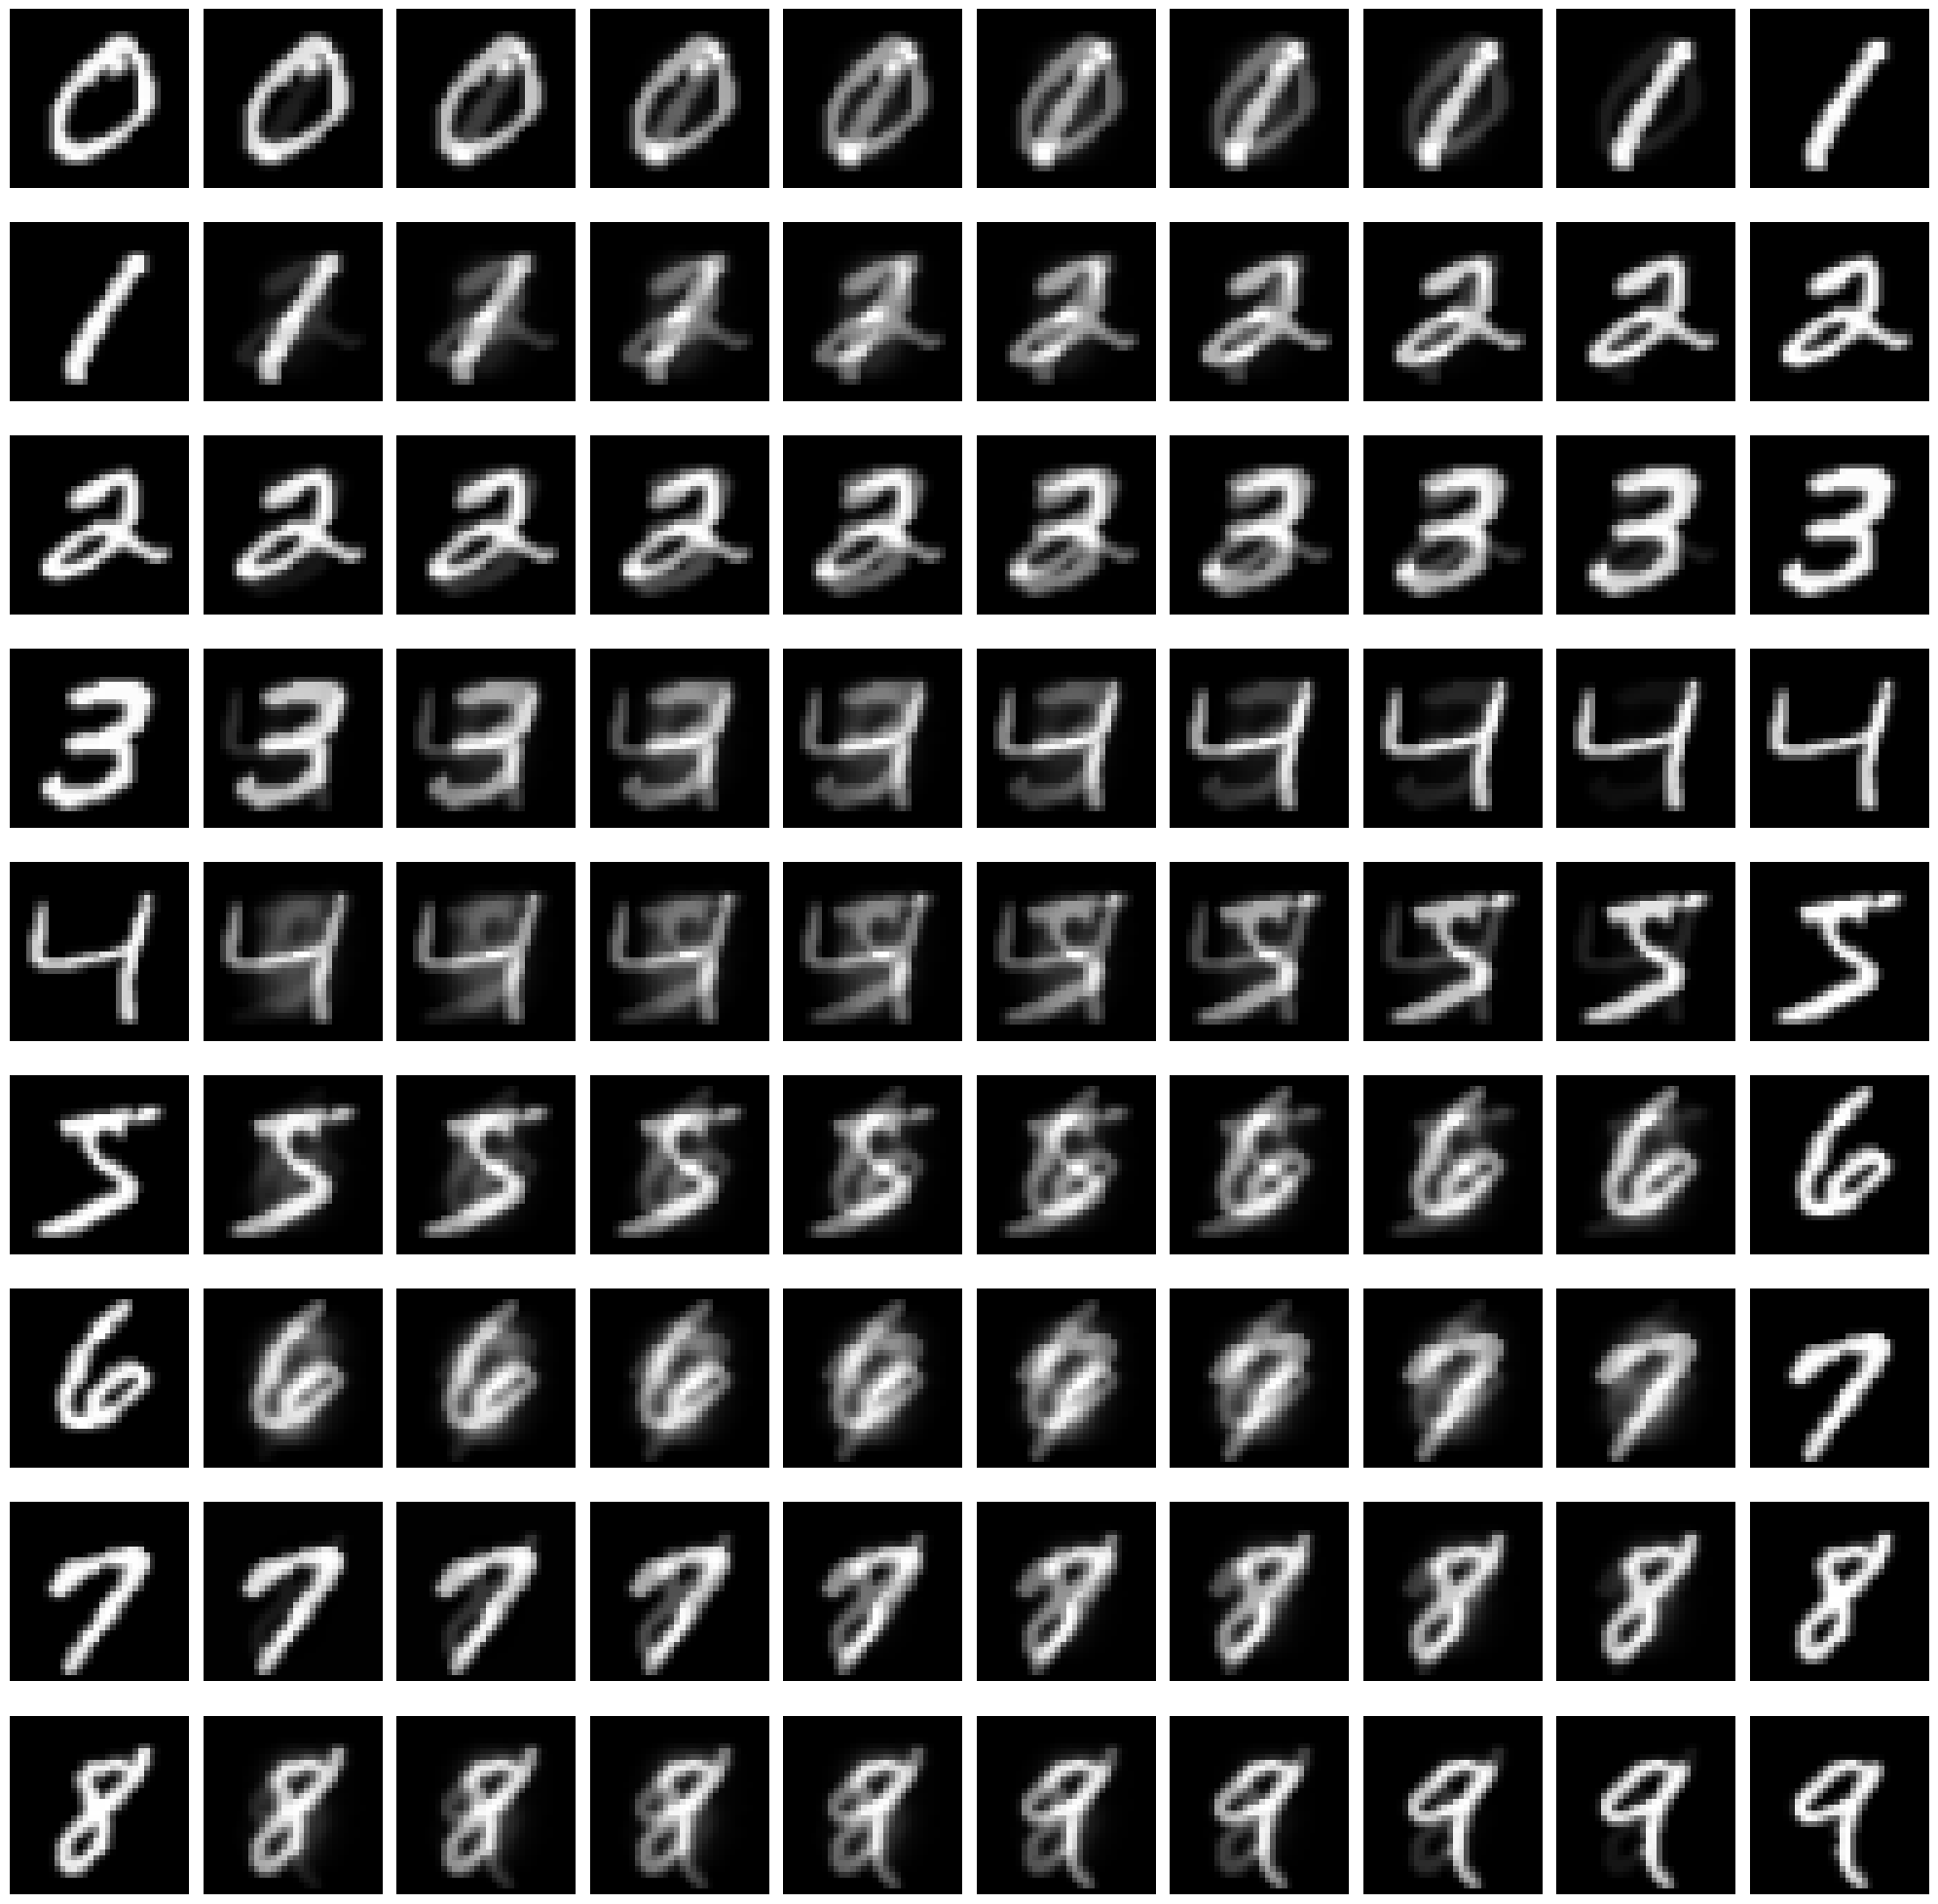

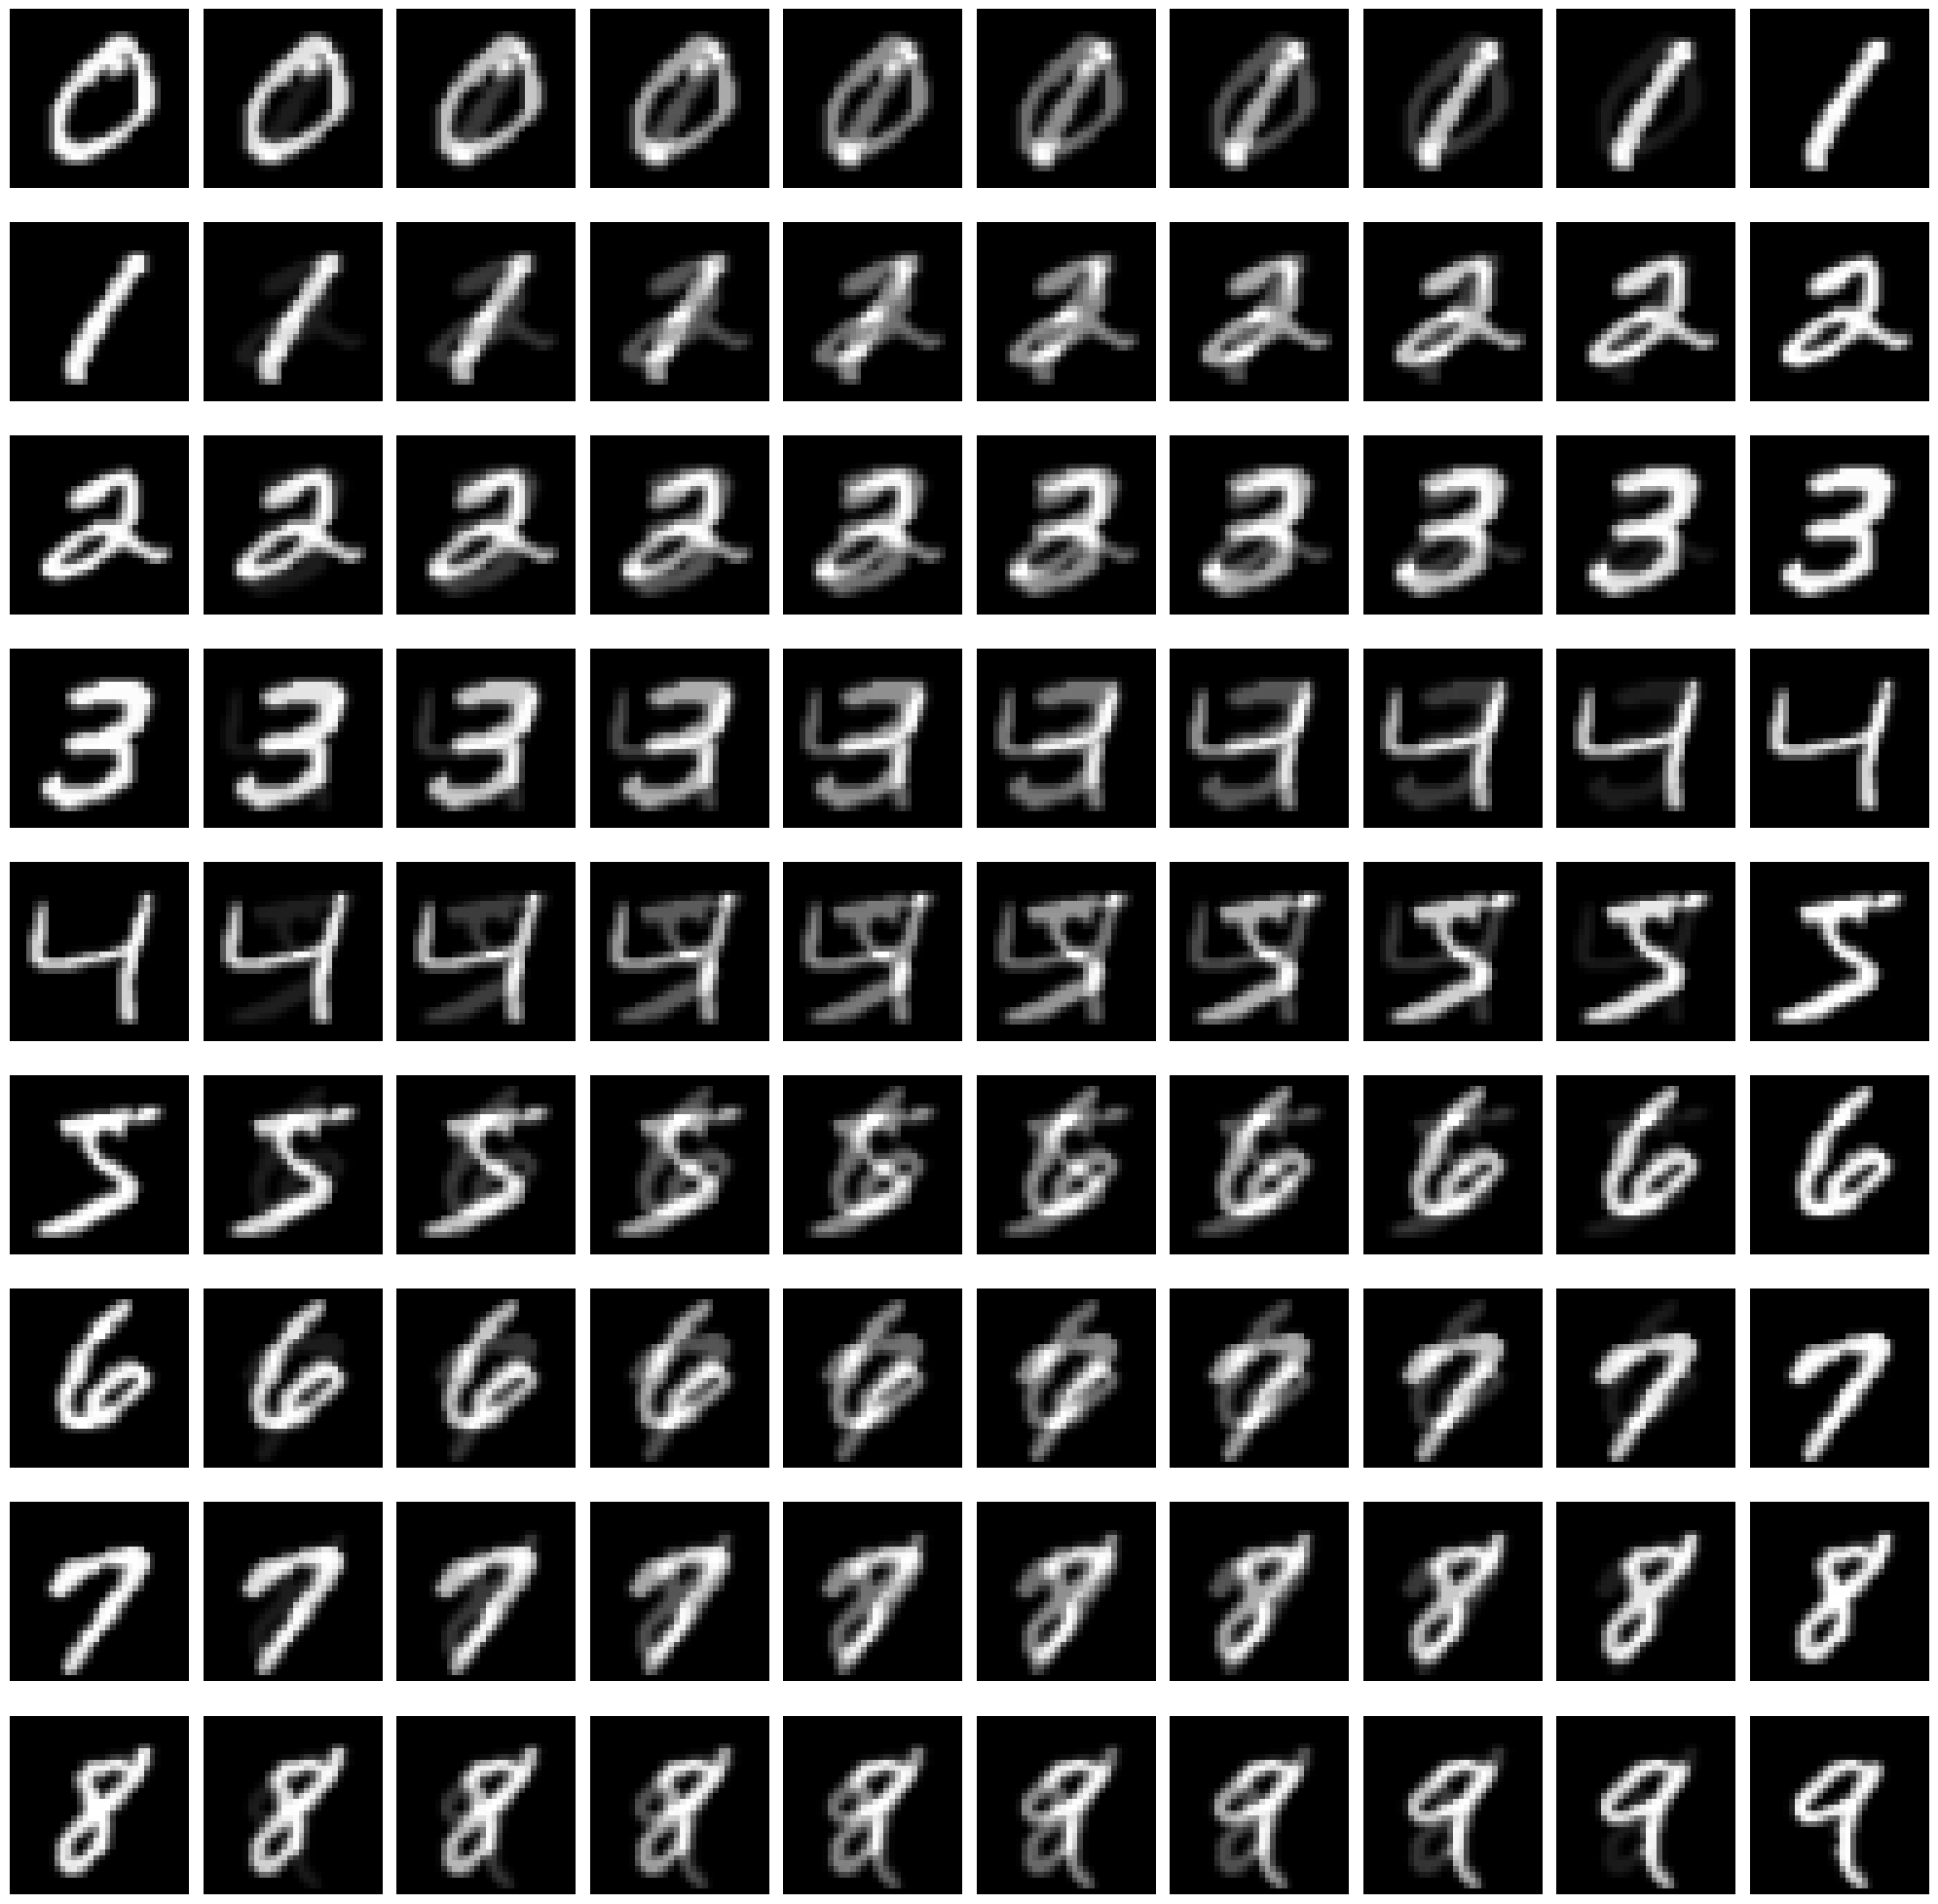

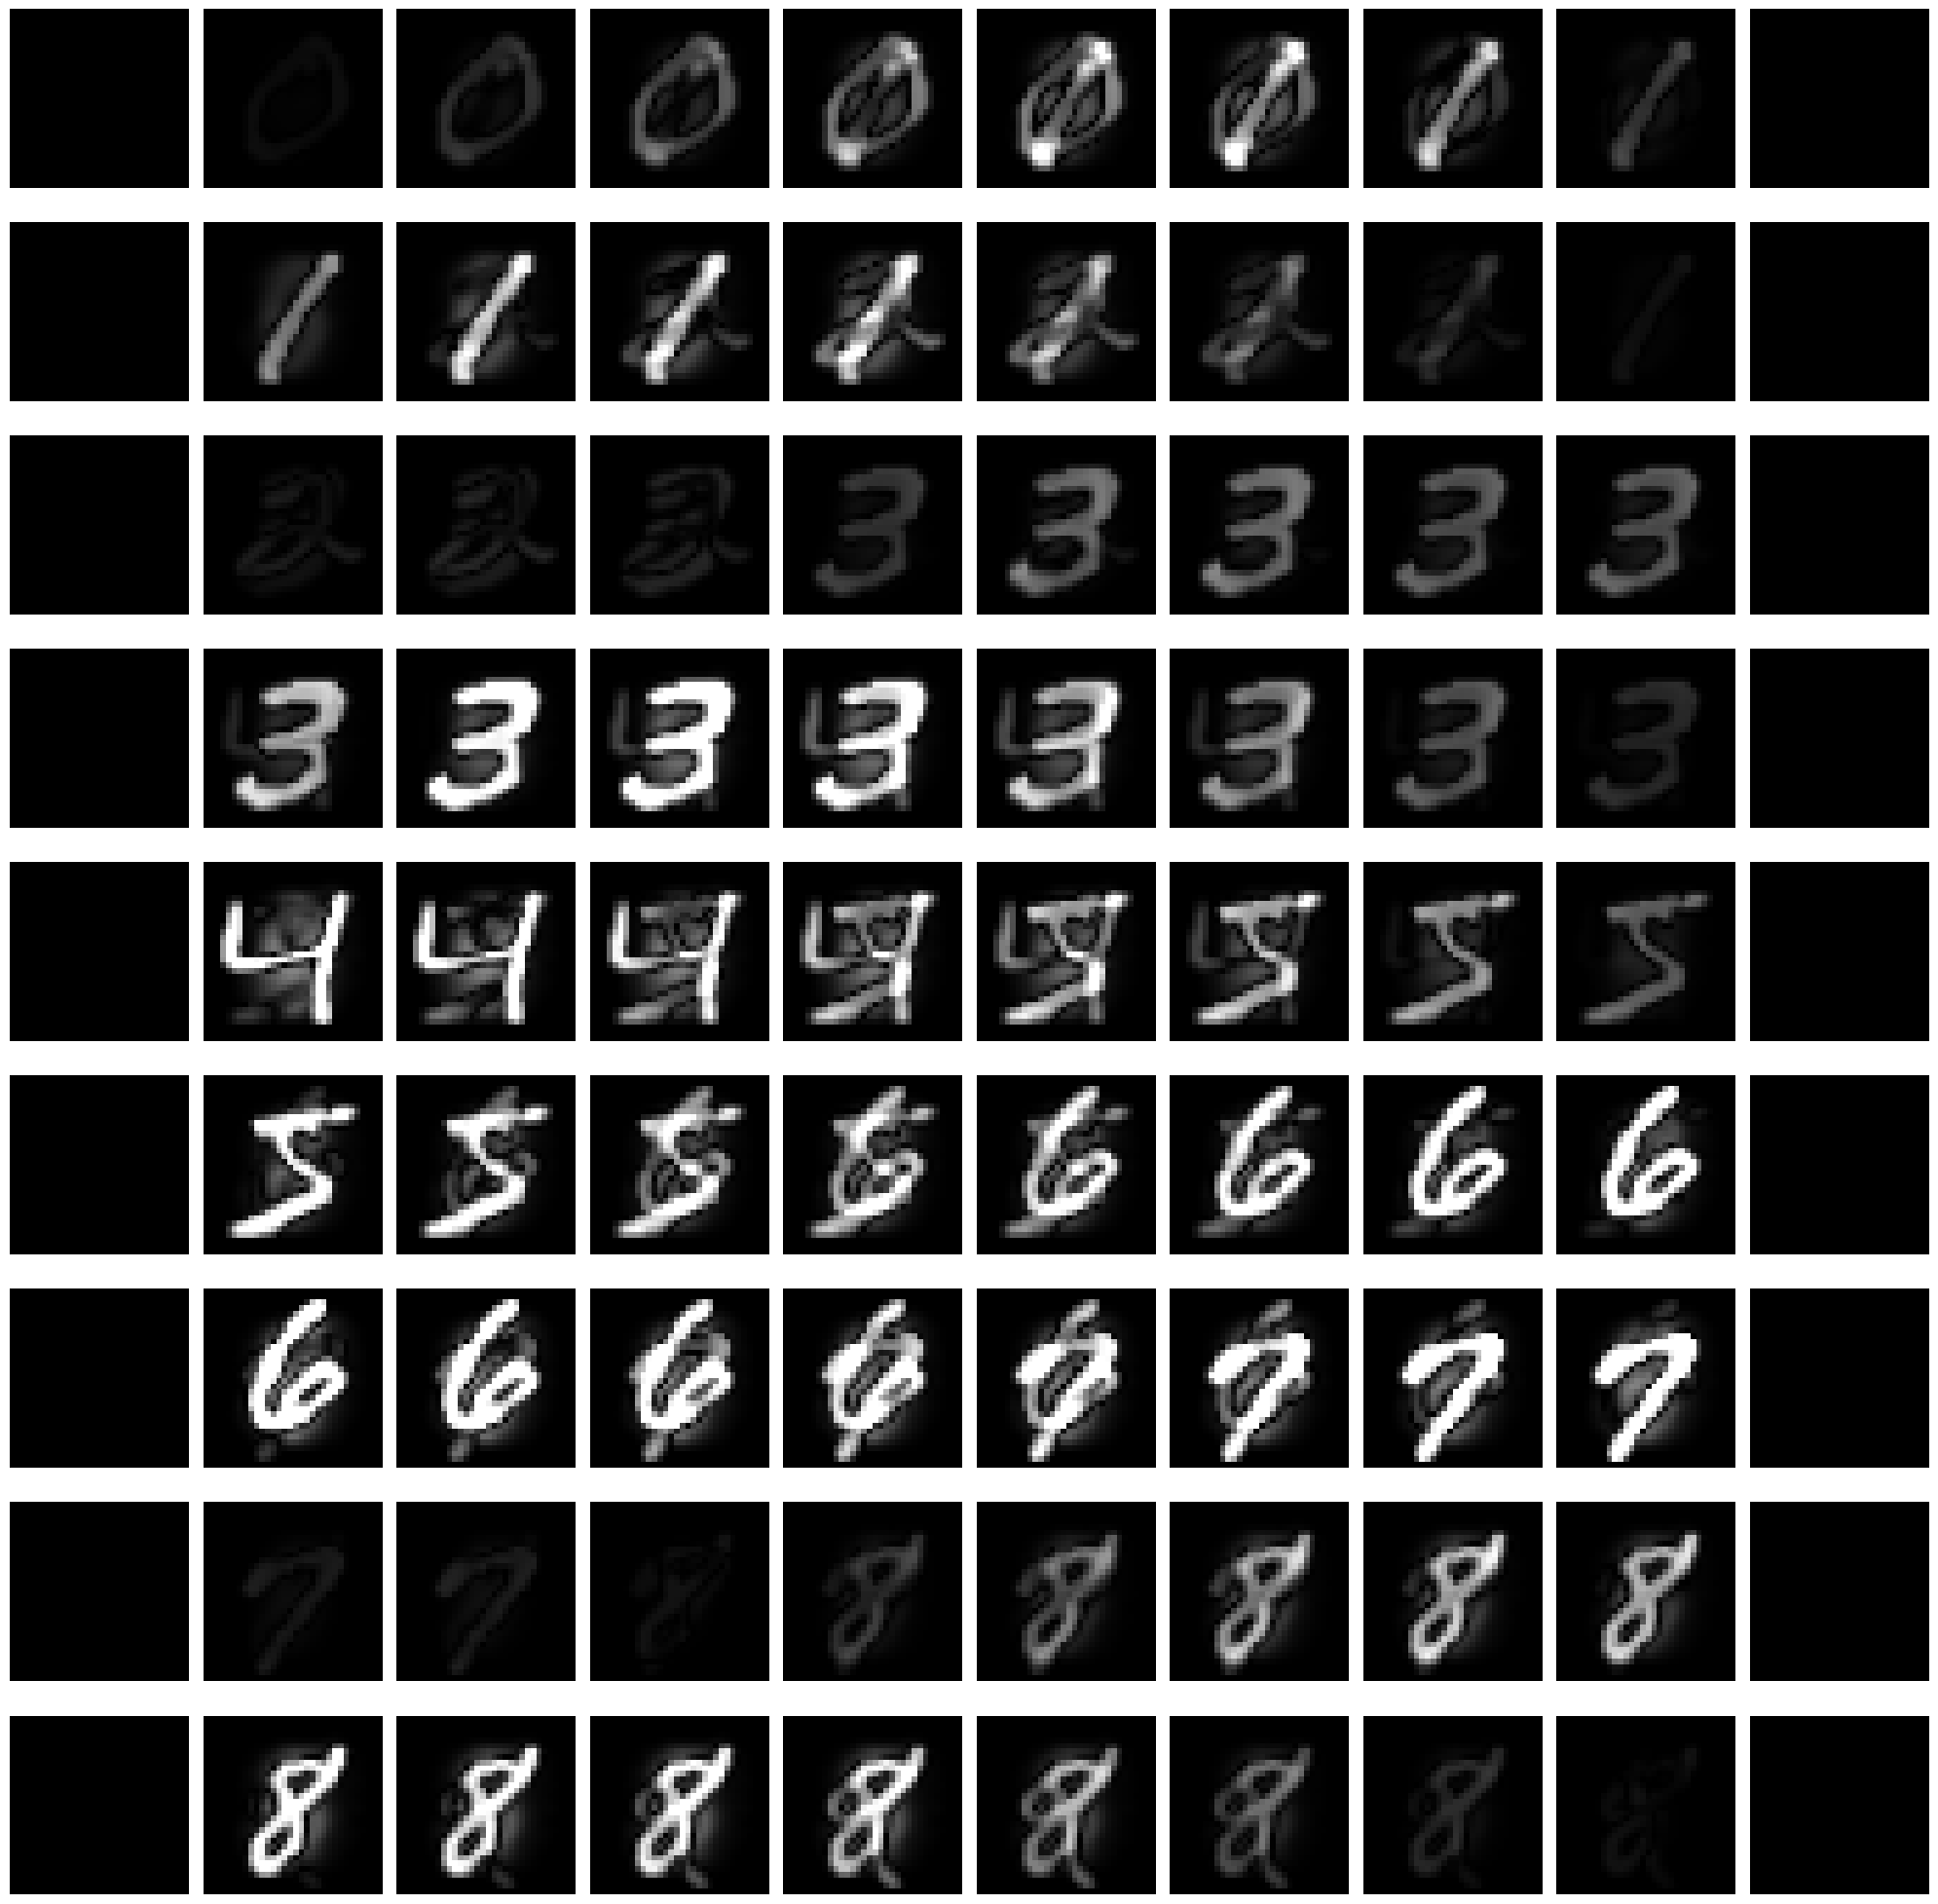

In [19]:
# compute geodesics between all pairs of points
steps = 10
t = torch.linspace(0, 1, steps=steps)
with torch.no_grad():
    geodesics = manifold.geodesic(data_clusters[None], data_clusters[None], t)[0] 
    interpolations = l2_euclidean.geodesic(data_clusters[None], data_clusters[None], t)[0]

# plot geodesics
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps):
        axes[i*steps + k].imshow(geodesics[i, i+1, k, 0], cmap='gray')
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics.png"))
plt.show()

# plot interpolations
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps): # have same color scale for all plots
        axes[i*steps + k].imshow(interpolations[i, i+1, k, 0], cmap='gray')
        axes[i*steps + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"linear_interpolations.png"))
plt.show()

# plot differences
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps): # have same color scale for all plots
        axes[i*steps + k].imshow((geodesics[i, i+1, k, 0] - interpolations[i, i+1, k, 0]).abs(), cmap='gray', vmin=0., vmax=1.)
        axes[i*steps + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"differences.png"))
plt.show()